# 02 — Exploratory analysis

Input: `data/processed/rpw_quotes_long.parquet` (built by `python -m rpw.build`).

**Read this first.** The unit is a *surveyed price quote*, not a transaction. The World Bank chooses which corridors and providers to survey, and the sample changes over time. No volumes or market shares exist, so every average here is an **unweighted** mean over quotes. All results are descriptive; none is causal.

**Default population:** `complete_cost_eligible` quotes at USD 200 (`cc1`). These are quotes with a disclosed FX margin and a valid, de-duplicated cost identity (see `docs/pipeline.md`). The *latest window* is the last four surveyed quarters: 2024_3Q, 2024_4Q, 2025_1Q and 2025_3Q (2025_2Q was not surveyed).

In [1]:
import json, pandas as pd
from IPython.display import Image, display
from rpw import analysis, config
F = analysis.run()  # regenerates outputs/tables/eda/*.csv and outputs/charts/*.png
T = analysis.TABLES
print(json.dumps(F['population'], indent=1))

{
 "quotes_total": 507920,
 "complete_cost_eligible_cc1": 245469,
 "latest_window": [
  "2024_3Q",
  "2024_4Q",
  "2025_1Q",
  "2025_3Q"
 ]
}


## 1–2. Cost level and trend

The mean of all quotes and the median of all quotes both mix price changes with sample changes. The **fixed panel** keeps only corridor × provider pairs surveyed in both 2016_2Q and 2025_3Q. It separates the two effects within the POST schema. The 2016 schema change is marked on the chart; cost fields are defined the same way in both sheets.

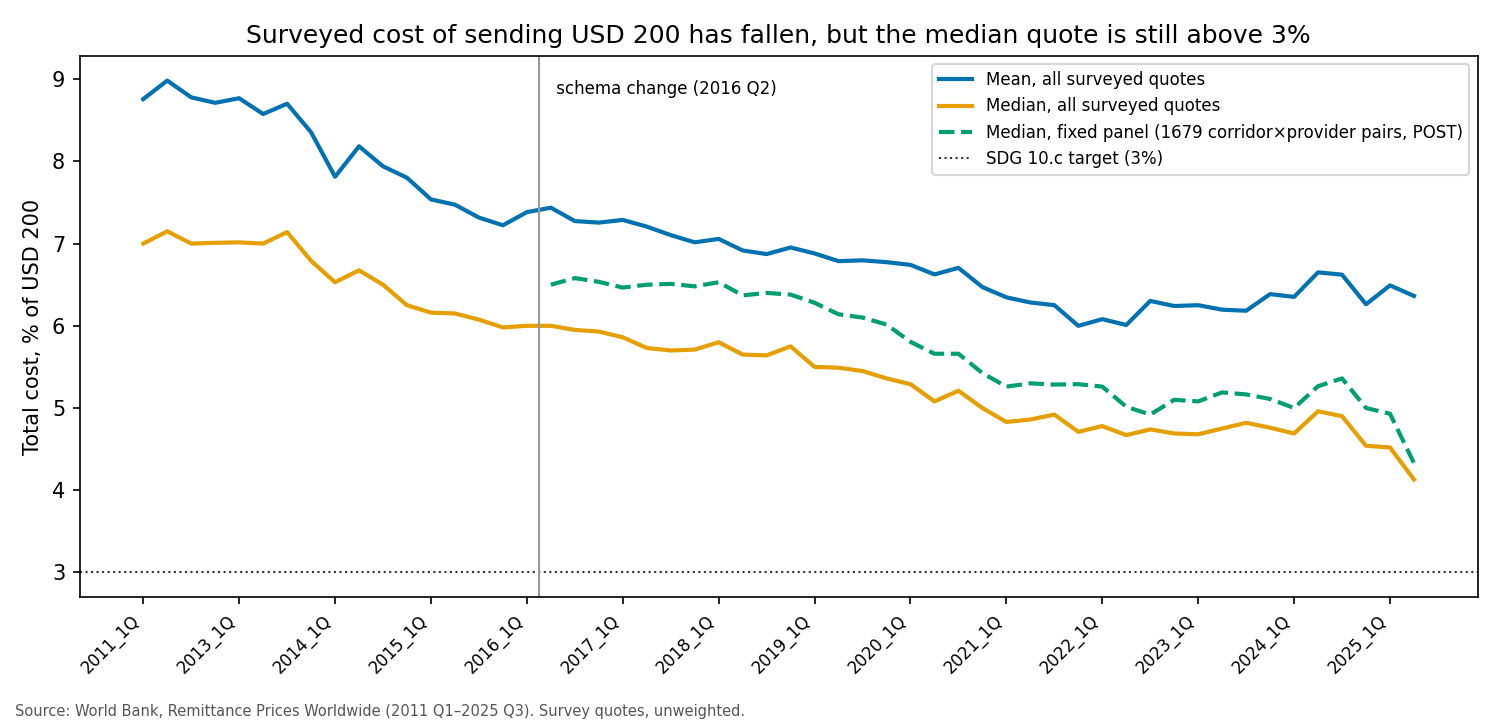

{'first_period': '2011_1Q', 'first_mean': np.float64(8.76), 'mean_2016_2Q': np.float64(7.44), 'mean_2025_3Q': np.float64(6.36), 'median_2016_2Q': np.float64(6.0), 'median_2025_3Q': np.float64(4.13), 'panel_pairs': 1679, 'panel_median_2016_2Q': np.float64(6.5), 'panel_median_2025_3Q': np.float64(4.33)}


In [2]:
display(Image(str(analysis.CHARTS / '01_cost_trend_cc1.png')))
print(F['trend'])

## 1. Corridors (latest window)

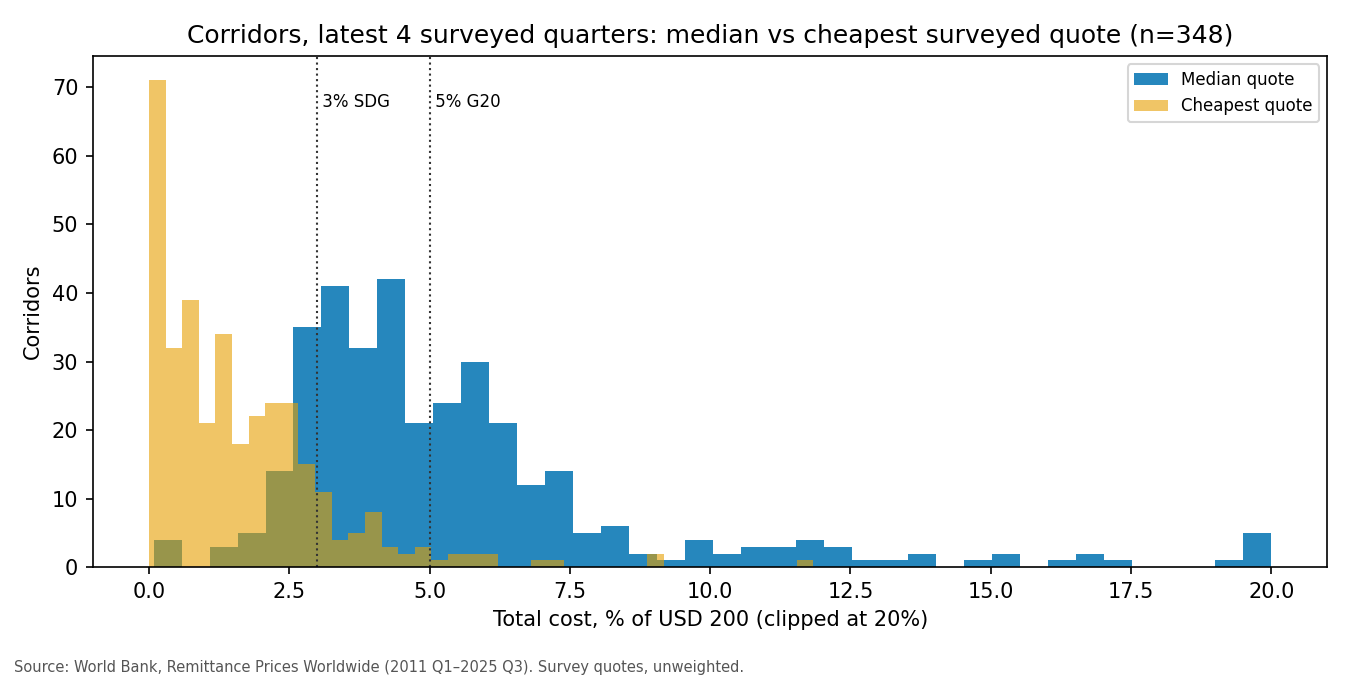

{'n_corridors': 348, 'median_of_corridor_medians': np.float64(4.5), 'share_corridor_median_gt_5': np.float64(43.4), 'share_corridor_median_le_3': np.float64(15.5), 'share_cheapest_le_3': np.float64(87.6), 'median_spread_p10_pp': np.float64(2.22)}


,corridor_key,source_name,destination_name,quotes,providers,median_total,min_total,p10,max_total,p25,p75,share_digital,spread_median_minus_p10
0,TZAKEN,Tanzania,Kenya,42,9,83.170,0.72,8.313,91.77,11.695,86.570,0.119,74.857
1,TZAUGA,Tanzania,Uganda,40,7,73.755,1.30,9.357,92.64,66.120,78.910,0.100,64.398
2,TURBGR,Türkiye,Bulgaria,48,10,67.200,11.84,12.790,307.20,19.682,124.148,0.438,54.410
3,TZARWA,Tanzania,Rwanda,24,6,43.885,6.01,8.014,97.89,10.048,73.900,0.167,35.871
4,SENMLI,Senegal,Mali,23,6,26.880,1.50,1.500,37.63,15.045,30.645,0.174,25.380
5,ZAFCHN,South Africa,China,38,6,19.360,3.76,15.813,38.06,16.550,32.790,0.158,3.547
6,THACHN,Thailand,China,70,10,17.335,2.51,4.530,21.57,5.738,18.892,0.500,12.805
7,ZAFMWI,South Africa,Malawi,101,14,16.740,0.39,-35.280,87.71,0.420,32.940,0.356,52.020
8,ZAFAGO,South Africa,Angola,60,9,16.550,6.12,8.063,33.89,9.540,22.083,0.383,8.487
9,THAMMR,Thailand,Myanmar,59,10,16.300,0.26,0.332,31.79,1.850,19.205,0.424,15.968


In [3]:
display(Image(str(analysis.CHARTS / '02_corridor_cost_distribution.png')))
print(F['corridors'])
pd.read_csv(T / 'corridor_costs_latest_window_cc1.csv').head(15)

## 3. USD 200 vs USD 500

The comparison is paired, using the same record at both amounts. Fees are largely fixed, so the fee share falls as the amount rises; the FX margin is a percentage and stays about the same.

In [4]:
pd.read_csv(T / 'amount_comparison_latest_window.csv')

,scenario,median_total,mean_total,mean_fee_pct,mean_fx_margin,paired_records
0,USD 200 (cc1),4.50,6.448,4.422,2.026,26245
1,USD 500 (cc2),3.13,4.227,2.211,2.016,26245


## 4–5. Fee vs FX margin, provider types

Means are pulled up by extreme quotes (e.g. TURBGR, where a fixed fee exceeds the amount sent), so medians are shown alongside them. The Non-bank FI group has only 12 quotes.

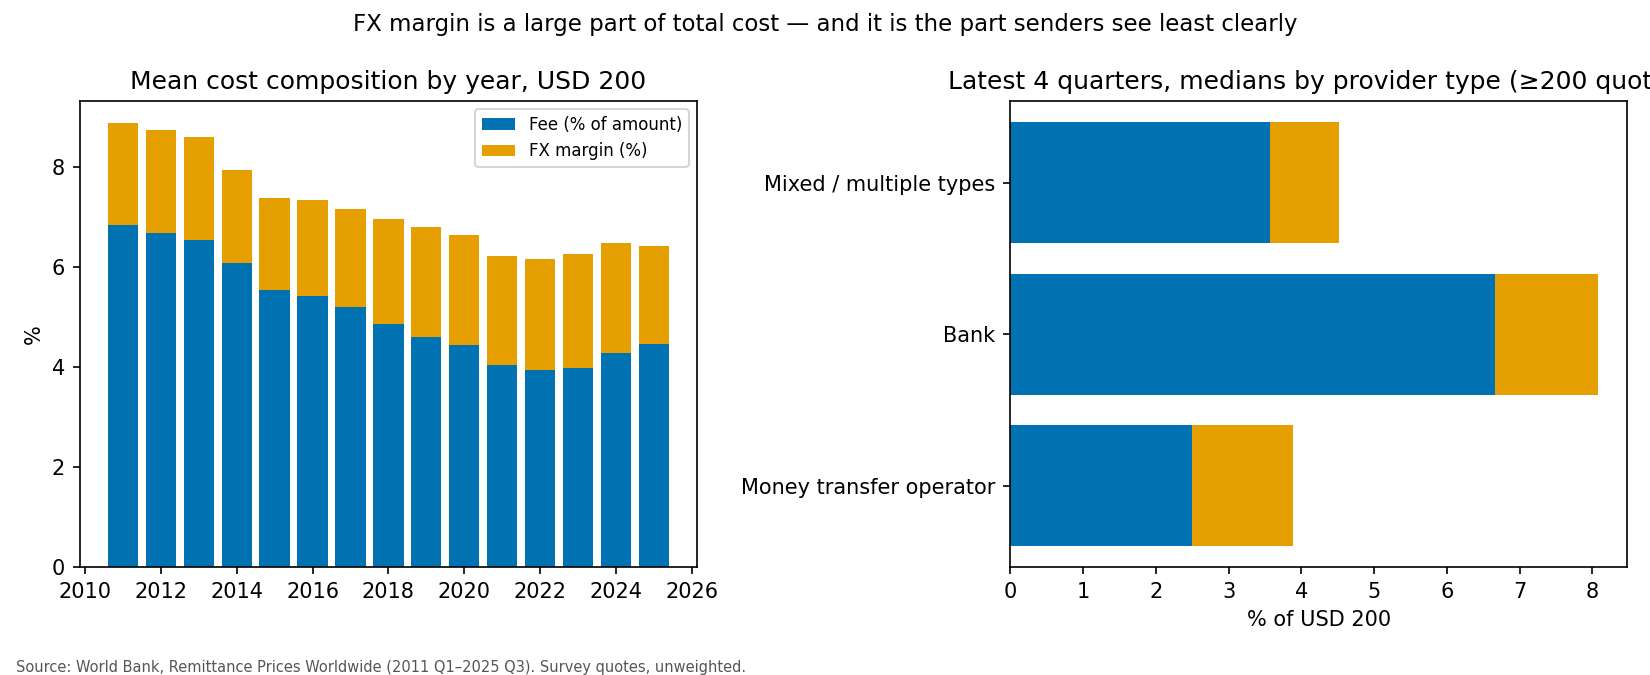

,provider_type,quotes,mean_fee_pct,mean_fx_margin,median_total,median_fee_pct,median_fx_margin,share_zero_fee,fx_share_of_cost
0,Money transfer operator,21807,3.068,1.982,4.240,2.495,1.390,0.096,0.392
1,Bank,3882,11.800,2.257,9.655,6.667,1.410,0.094,0.161
2,Mixed / multiple types,525,5.088,1.970,5.060,3.564,0.950,0.019,0.279
3,Mobile operator,92,2.147,1.273,2.660,1.838,0.390,0.011,0.372
4,Post office,85,5.731,0.806,7.140,7.143,0.130,0.188,0.123
5,Non-bank financial institution,12,35.231,15.155,71.245,50.108,20.905,0.000,0.301


In [5]:
display(Image(str(analysis.CHARTS / '03_fee_vs_fx_composition.png')))
pd.read_csv(T / 'provider_type_costs_latest_window_cc1.csv')

### Access channel (digital vs physical)

The channel comes from PRE `sending location` / POST `access point` (an assumption-bearing mapping). The within-corridor comparison controls for corridor mix but not for provider or payout method.

In [6]:
print(F['channel']); print(F['channel_within_corridor'])

{'Digital only': {'quotes': 16273, 'median_total': 4.05, 'mean_fee': 2.91, 'mean_fx': 2.05}, 'Physical only': {'quotes': 10130, 'median_total': 5.88, 'mean_fee': 6.83, 'mean_fx': 1.98}}
{'corridors_with_both': 326, 'median_gap_pp': np.float64(1.89), 'share_digital_cheaper_pct': np.float64(81.0)}


## 6. Transparency and data-quality limits

Audit finding M3: the `transparent` flag stops being used after 2021, while notes still describe non-transparent services. `fx_margin_disclosed` combines the flag with the note text.

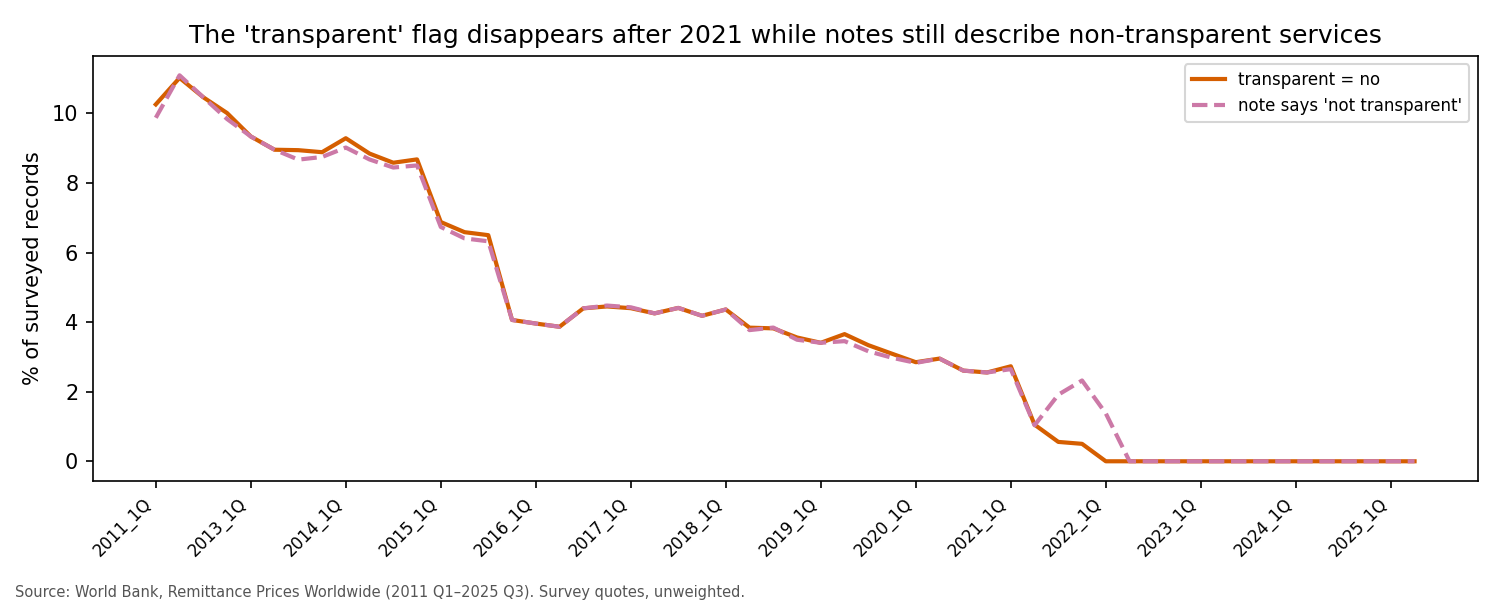

{'pre_share_undisclosed': np.float64(8.2), 'post_share_undisclosed': np.float64(1.8), 'complete_eligible_pct': np.float64(96.7)}


In [7]:
display(Image(str(analysis.CHARTS / '04_transparency_coding.png')))
print(F['transparency'])

## 7. Sending and receiving markets

Region labels changed during the POST period: the old and new MENA labels both appear, and `..` is a source token. They are reported as recorded.

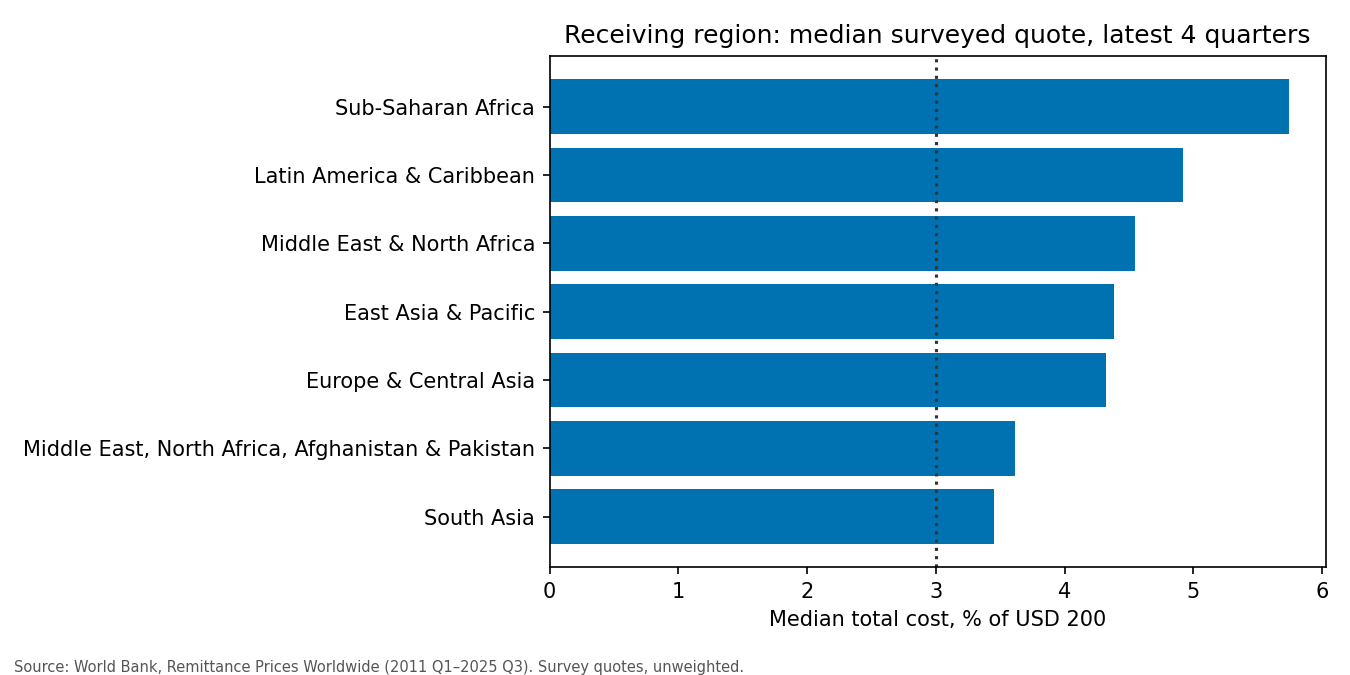

,source_name,quotes,corridors,median_total
0,Côte d'Ivoire,34,1,2.58
1,Kuwait,624,6,2.70
2,Costa Rica,36,1,2.75
43,Senegal,23,1,26.88
44,Türkiye,48,1,67.20
45,Tanzania,106,3,73.34


In [8]:
display(Image(str(analysis.CHARTS / '05_receiving_region_costs.png')))
pd.read_csv(T / 'sending_market_costs_latest_window_cc1.csv').sort_values('median_total').iloc[[0,1,2,-3,-2,-1]]

## 8. Potentially underserved corridors (screen, not a verdict)

The screen marks a corridor when no surveyed non-negative quote is ≤3% or ≤5%, or when no digital quote exists. The dispersion measure is median − 10th percentile, which is robust to negative promotional quotes. Remember that a corridor appears only if the World Bank surveyed it.

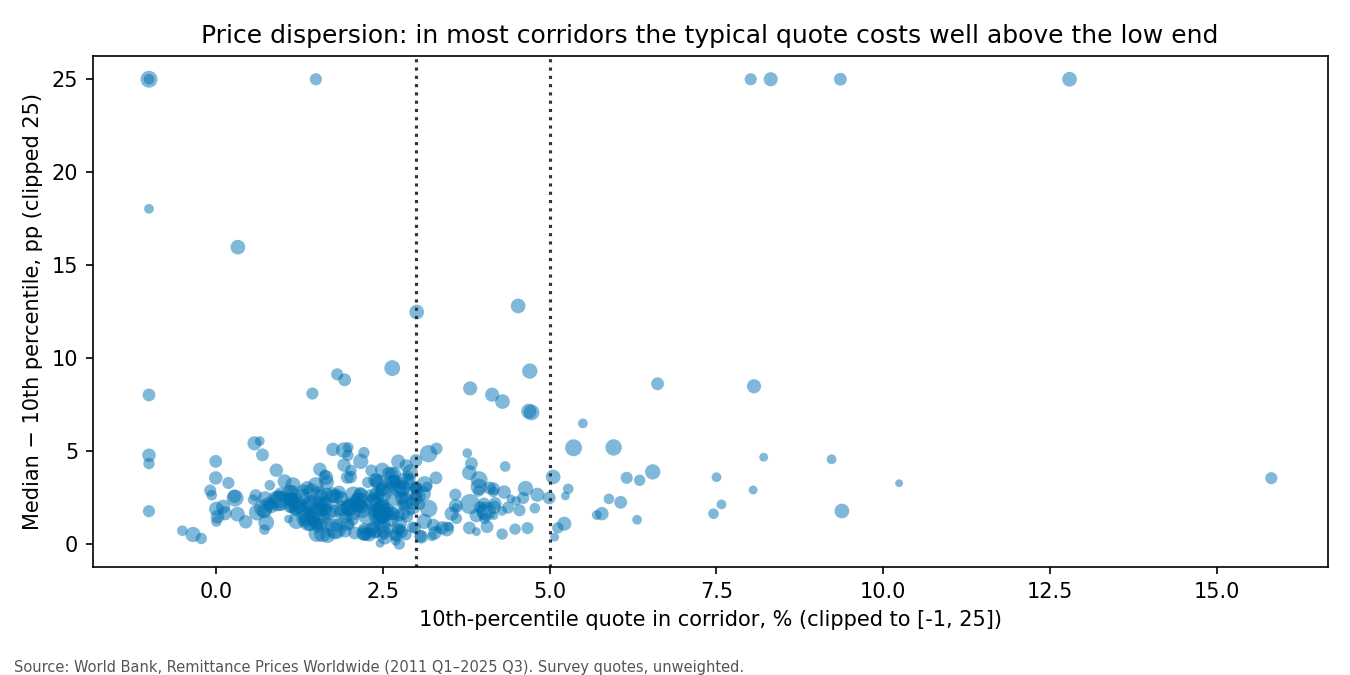

{'corridors': 348, 'no_quote_le_3': 43, 'no_quote_le_5': 12, 'no_digital_quote': 19, 'top_no_quote_le_5': [['TURBGR', 11.84], ['ISRMAR', 8.93], ['SAUSYR', 8.88], ['GBRGMB', 7.21], ['USAAFG', 6.87], ['ZAFAGO', 6.12], ['TZARWA', 6.01], ['DOMHTI', 5.76], ['GBRAFG', 5.69], ['AGONAM', 5.61]], 'share_corridors_gap_ge_2pp': np.float64(57.5), 'median_gap_median_to_p10_pp': np.float64(2.22), 'negative_total_quotes_excluded_from_cheapest': 344}


,corridor_key,source_name,destination_name,destination_region,providers,quotes,min_total,p10,median_total,digital_quotes,min_digital_total,no_quote_le_3pct,no_quote_le_5pct,savings_median_to_p10_pp
0,TURBGR,Türkiye,Bulgaria,Europe & Central Asia,10,48,11.84,12.790,67.200,21,18.52,True,True,54.410
1,ISRMAR,Israel,Morocco,"Middle East, North Africa, Afghanistan & Pakistan",3,12,8.93,9.225,13.785,0,NaN,True,True,4.560
2,SAUSYR,Saudi Arabia,Syrian Arab Republic,"Middle East, North Africa, Afghanistan & Pakistan",1,4,8.88,10.236,13.510,0,NaN,True,True,3.274
3,GBRGMB,United Kingdom,"Gambia, The",Sub-Saharan Africa,10,91,7.21,9.380,11.160,75,7.21,True,True,1.780
4,USAAFG,United States,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",3,24,6.87,7.576,9.710,13,6.87,True,True,2.134
5,ZAFAGO,South Africa,Angola,Sub-Saharan Africa,9,60,6.12,8.063,16.550,23,6.12,True,True,8.487
6,TZARWA,Tanzania,Rwanda,Sub-Saharan Africa,6,24,6.01,8.014,43.885,4,6.01,True,True,35.871
7,DOMHTI,Dominican Republic,Haiti,Latin America & Caribbean,3,12,5.76,6.312,7.620,0,NaN,True,True,1.308
8,GBRAFG,United Kingdom,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",2,21,5.69,8.050,10.960,8,7.54,True,True,2.910
9,AGONAM,Angola,Namibia,Sub-Saharan Africa,2,7,5.61,8.208,12.880,0,NaN,True,True,4.672


In [9]:
display(Image(str(analysis.CHARTS / '06_corridor_dispersion.png')))
print(F['underserved'])
pd.read_csv(T / 'underserved_corridor_screen_latest_window_cc1.csv').head(15)

See `docs/eda_findings.md` for the written interpretation and its limitations.